In [3]:
from cil.framework import  AcquisitionGeometry, DataContainer

from cil.framework import BlockDataContainer

from cil.optimisation.algorithms import Algorithm
from cil.optimisation.operators import BlockOperator, GradientOperator, IdentityOperator, FiniteDifferenceOperator

from cil.optimisation.functions import SumFunction, L2NormSquared, L1Norm, L1Sparsity, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares
from cil.optimisation.operators import GradientOperator, BlockOperator
from cil.optimisation.algorithms import GD, PDHG, SIRT, FISTA

from cil.plugins.astra.operators import ProjectionOperator
from cil.plugins.astra.processors import FBP
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.plugins.ccpi_regularisation.functions import FGP_dTV 

from cil.utilities.display import show2D, show1D, show_geometry
from cil.utilities.jupyter import islicer

from cil.io import ZEISSDataReader
from cil.io import TIFFStackReader, TIFFWriter

from cil.processors import CentreOfRotationCorrector, Slicer, \
    Binner, Masker, MaskGenerator, TransmissionAbsorptionConverter, Normaliser

import matplotlib.pyplot as plt

import numpy as np

import os

from os import makedirs, listdir
from os.path import join, exists
#from tkinter.filedialog import askdirectory, askopenfilename # Allows the code to get the directory of user-selected folder
from PIL import Image
from imageio import imread, get_writer

In [15]:
import module_auxiliary as ma
from astropy.io import fits
path = '/dtu-compute/msaca/sliceB_neutron_dtu/sliceB_neutron_psi/02_rawdata/01_tomo/tomo_#####.fits'
A = range(1,1127)
paths = ma.generate_paths(path, A)

image_stack = []
for file_path in paths:
    # Open the FITS file and read its data
    with fits.open(file_path) as hdul:
        # Extract the image data (assuming it's in the primary HDU)
        image_data = hdul[0].data
        image_stack.append(image_data)

# Convert the list of 2D arrays into a 3D NumPy array
image_stack_3d = np.array(image_stack)

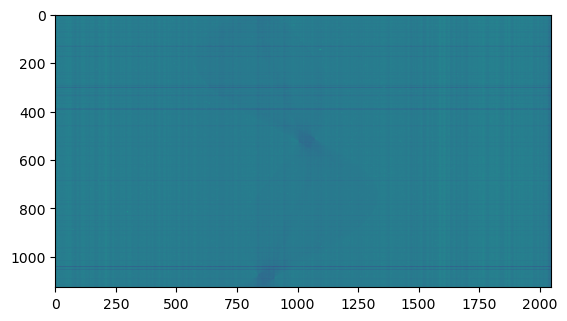

In [20]:
plt.imshow(np.log(image_stack_3d[:,500,:]))

In [ ]:



detector_rows = dims[0]
detector_columns = dims[1]

# Defining geometry first
ag3D = AcquisitionGeometry.create_Cone3D(source_position=[0,0, 0],detector_position=[0,0,0], units='mm')  \
         .set_panel(num_pixels=(detector_rows, detector_columns), pixel_size = 0.2,  origin='top-left')        \
         .set_angles(angles=-np.linspace(0, 2* np.pi,len(os.listdir(path)),endpoint=True), angle_unit = 'radian')  \
         .set_labels(['angle','vertical','horizontal'])

reader = TIFFStackReader(file_name = path, dtype= np.float32)
print("Reading image data...")
data3D = reader.read_as_AcquisitionData(ag3D) # Save images from folder to a variable.
print("Done")